ECEN 743: Assignment 6
==============

**Author:** *Brody Jordan*\
**UIN:** 431005357\
**Description:** In this assignment, you will implement and evaluate modern Deep Reinforcement Learning algorithms on high-dimensional continuous control tasks. You will use the MuJoCo environments from Gymnasium, specifically focusing on the Pusher and Humanoid environments.

---

# Report

## (a) Hyperparameters

Configured hyperparameters:

### Reinforcement Learning Hyperparameters

| Parameter | PPO Value | SAC Value | Description |
| :--- | :--- | :--- | :--- |
| **Policy Type** | `MlpPolicy` | `MlpPolicy` | Multi-layer Perceptron (Standard neural network). |
| **Learning Rate** | `3e-4` | `3e-4` | The step size for the optimizer. |
| **Batch Size** | `128` | `256` | Number of samples used for each gradient update. |
| **Device** | `cuda` | `auto` | Hardware used for training (GPU vs. Auto-detect). |
| **n_steps** | `2048` | *N/A* | Number of steps to run per environment per update. |
| **n_epochs** | `10` | *N/A* | Number of passes over the training data per update. |
| **Buffer Size** | *N/A* | `1,000,000` | Size of the replay buffer (experience memory). |
| **Tau ($\tau$)** | *N/A* | `0.005` | Soft update coefficient for target networks. |
| **Gamma ($\gamma$)** | *N/A* | `0.99` | Discount factor for future rewards. |
| **Train Freq** | *N/A* | `1` | Update the model every `n` steps. |
| **Gradient Steps** | *N/A* | `1` | How many gradient steps to take after each rollout. |
| **Learning Starts** | *N/A* | `10,000` | Steps to take to fill the buffer before learning begins. |

## (b) Training Graphs

Please see below in the code section! :)

## (c) Findings & Comparison

For PPO, I was able to use multiple environments via

```
make_vec_env
```
which massively improved training times for both Pusher and Humanoid. This is not avaialble for SAC, however so training times there tended to be significantly longer.


# Code

In [1]:
import sys
print(sys.executable)

/usr/bin/python3


## 1. Environment Setup

In [2]:
!apt-get update
!apt-get install -y xvfb libgl1-mesa-dev libgl1-mesa-glx libglew-dev libosmesa6-dev
!pip install pyvirtualdisplay moviepy stable-baselines3[extra] gymnasium[mujoco]

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libglew-dev is already the newest version (2.2.0-4).
libgl1-mesa-dev is already the newest ver

In [3]:
import os
os.environ["MUJOCO_GL"] = "osmesa"

In [4]:
import os
import torch
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from gymnasium.wrappers import RecordVideo

In [5]:
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecMonitor

In [6]:
class _RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards, self.timesteps = [], []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.rewards.append(info["episode"]["r"])
                self.timesteps.append(self.num_timesteps)
        return True


def train(env_name, algo_name, timesteps=1000000):

    if algo_name.lower() == "ppo":
        n_envs = 40
        env = make_vec_env(env_name, n_envs=n_envs, vec_env_cls=SubprocVecEnv)

        model = PPO("MlpPolicy", env, device="cuda",
                    n_steps=2048, batch_size=128, n_epochs=10, learning_rate=3e-4, verbose=0)

    elif algo_name.lower() == "sac":
        env = DummyVecEnv([lambda: gym.make(env_name)])
        env = VecMonitor(env)
        model = SAC("MlpPolicy", env, verbose=0, buffer_size=1_000_000,
                    learning_rate=3e-4, batch_size=256, tau=0.005, gamma=0.99, train_freq=1,
                    gradient_steps=1, learning_starts=10_000, device="auto")


    logger = _RewardLogger()
    model.learn(timesteps, callback=logger, progress_bar=True)

    env.close()

    path = f"models/{algo_name}_{env_name}"
    os.makedirs("models", exist_ok=True)

    model.save(path)
    print(f"Model saved to {path}")

    return dict(
        model=model,
        rewards=logger.rewards,
        timesteps=logger.timesteps,
        env_name=env_name,
        algo_name=algo_name.upper(),
    )


In [7]:
def report(result, video_folder="videos", smooth_window: int = 100):
    """Plot the training curve and save a video of the trained agent."""
    rewards = np.array(result["rewards"])
    timesteps = np.array(result["timesteps"])
    label = f"{result['algo_name']} on {result['env_name']}"

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(timesteps, rewards, alpha=0.25, color="blue", label="Episode reward")

    if len(rewards) >= smooth_window:
        k = np.ones(smooth_window) / smooth_window
        smoothed = np.convolve(rewards, k, mode="valid")
        ax.plot(
            timesteps[smooth_window - 1 :],
            smoothed,
            color="orangered",
            lw=2,
            label=f"Smoothed (w={smooth_window})",
        )

    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Episode Reward")
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    plt.show()

    os.makedirs(video_folder, exist_ok=True)
    prefix = f"{result['algo_name']}_{result['env_name']}"
    env = gym.make(result["env_name"], render_mode="rgb_array")
    env = RecordVideo(
        env, video_folder=video_folder, name_prefix=prefix,
        episode_trigger=lambda _: True,
    )

    model = result["model"]
    obs, _ = env.reset()
    done, ep_reward = False, 0.0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = env.step(action)
        ep_reward += r
        done = terminated or truncated
    env.close()
    print(f"Video saved to {video_folder}/{prefix}-episode-0.mp4  |  Reward: {ep_reward:.1f}")


## 2. Algorithm Training & Hyperparameter Tuning

### 2(a). PPO

#### Pusher

In [8]:
ppo_pusher = train("Pusher-v5", "ppo", timesteps=1000000)

Output()

Model saved to models/ppo_Pusher-v5


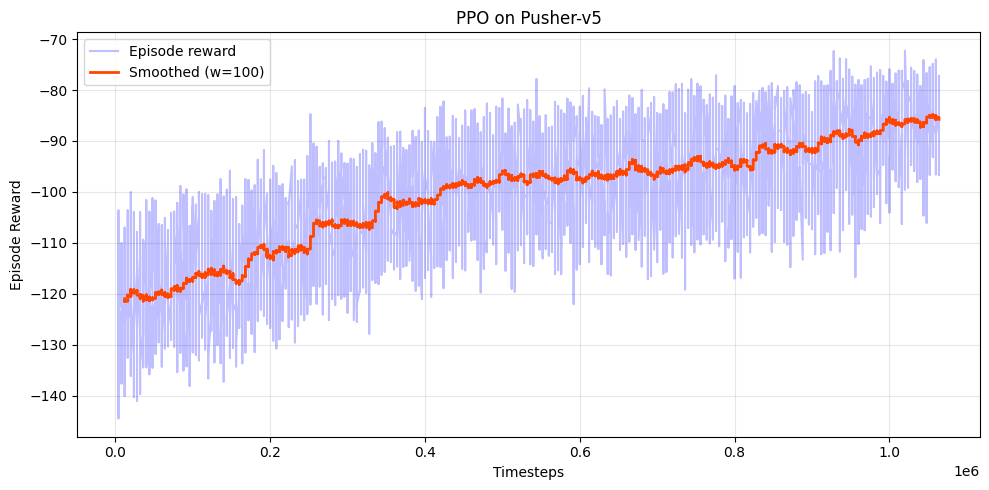

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video saved to videos/PPO_Pusher-v5-episode-0.mp4  |  Reward: -46.9


In [9]:
report(ppo_pusher)

#### Humanoid

In [10]:
ppo_humanoid = train("Humanoid-v5", "ppo", timesteps=2000000)

Output()

Model saved to models/ppo_Humanoid-v5


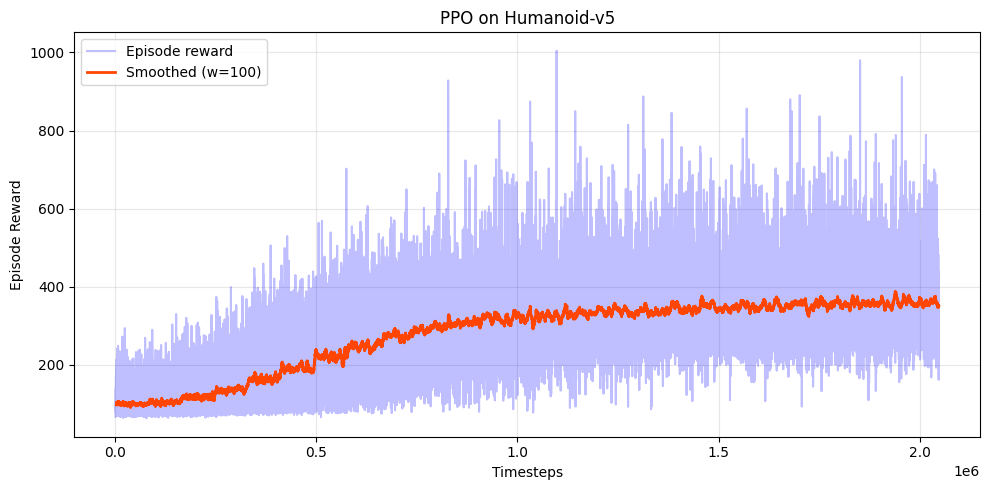

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video saved to videos/PPO_Humanoid-v5-episode-0.mp4  |  Reward: 332.4


In [11]:
report(ppo_humanoid)

### 2(b). SAC

#### Pusher

In [12]:
sac_pusher = train("Pusher-v5", "sac", timesteps=500000)

Output()

KeyboardInterrupt: 

In [ ]:
report(sac_pusher)

#### Humanoid

In [ ]:
sac_humanoid = train("Humanoid-v5", "sac", total_timesteps=3000000)

In [ ]:
report(sac_humanoid)

## 3. Inference & Video Generation